<a href="https://colab.research.google.com/github/MichaelWegener/SDP-302---Fall-2026/blob/main/OLS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression Model

Welcome! This notebook offers a hands-on introduction to linear regression in Python. Through a real-world example, you’ll learn both how to implement the model and understand the underlying econometric theory and OLS regression technique.



In [24]:
import pandas as pd
import numpy as np
import seaborn.objects as so
import statsmodels.api as sm
from tabulate import tabulate

df=pd.read_csv("https://raw.githubusercontent.com/MichaelWegener/SDP-302---Fall-2026/refs/heads/main/data/height_weight.csv")
df = sm.add_constant(df)

> Remark: To include an intercept term in a *statsmodels* regression, you need to use the *add_constant()* function. It simply adds a column of ones to your dataset. It feels like an extra, slightly clunky step, but it is a necessary quirk of how the library fits models. For a *pandas.DataFrame* the fuction will simply prepend a  column named *const* to the DataFrame.
A short guide on how to use the *add.constant()* function is also given on [.pyTutorial](https://pytutorial.com/python-statsmodels-add_constant-explained/)


In [25]:
print(tabulate(df, headers='keys', tablefmt='fancy_grid', showindex=False))

╒═════════╤═════════════╤═════════════╕
│   const │   Height_cm │   Weight_kg │
╞═════════╪═════════════╪═════════════╡
│       1 │       175   │        84.8 │
├─────────┼─────────────┼─────────────┤
│       1 │       168.6 │        70.6 │
├─────────┼─────────────┼─────────────┤
│       1 │       176.5 │        79.2 │
├─────────┼─────────────┼─────────────┤
│       1 │       185.2 │        79.6 │
├─────────┼─────────────┼─────────────┤
│       1 │       167.7 │        68.2 │
├─────────┼─────────────┼─────────────┤
│       1 │       167.7 │        71.4 │
├─────────┼─────────────┼─────────────┤
│       1 │       185.8 │        81.5 │
├─────────┼─────────────┼─────────────┤
│       1 │       177.7 │        81.8 │
├─────────┼─────────────┼─────────────┤
│       1 │       165.3 │        65.8 │
├─────────┼─────────────┼─────────────┤
│       1 │       175.4 │        76.4 │
├─────────┼─────────────┼─────────────┤
│       1 │       165.4 │        65.8 │
├─────────┼─────────────┼─────────────┤


As shown by the table above the dataset contains physical measurement records for two continuous numeric variables: Height (measured in inches above 5 foot) and Weight (measured in pounds).

Since humans process visual information much faster and better than text or tabular data we will visualise the relationship between these two variables in a scatterplot. The plot indicates a systematic positive linear relationship between height and weight. The data points cluster consistently around an upward-sloping linear trend: as height increases, body weight also reliably increases along a straight path.

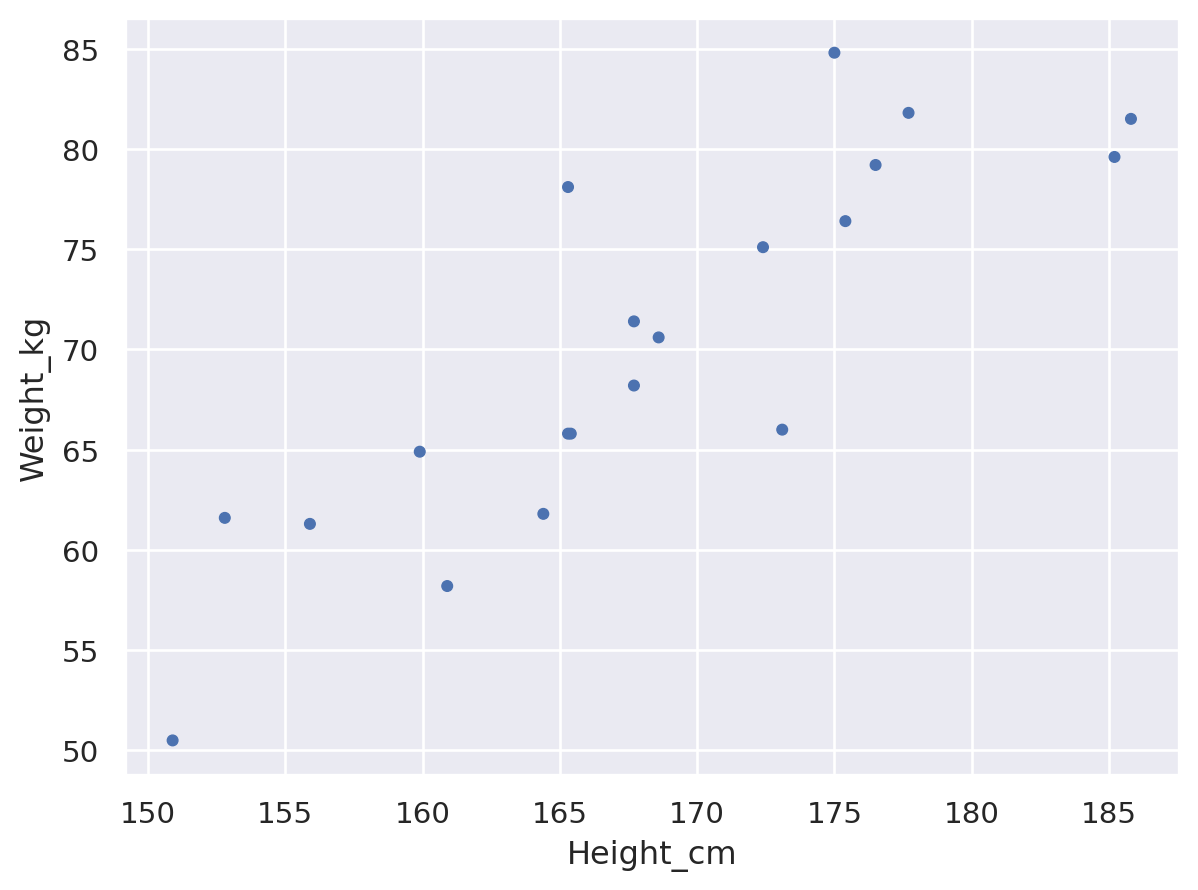

In [27]:
(
    so.Plot(df, x="Height_cm", y="Weight_kg")
    .add(so.Dot( pointsize=4))
)

Based on the scatterplot and common sense, we hypothesise that there should exist a true systematic relationship between the height and the weight of a person. This true relationship is generated by a true population function $f$ (the deterministic component) plus a stochastic error term $\epsilon$ reflecting nothing but some random noise:
\begin{equation}
Weight=f(Height)+\epsilon
\end{equation}

The crucial point is that we do not know - and can never know - the true generating function $f$. This is why it is sometimes called the true unknown function.

The aim of regression analysis is to approach this systematic relationship, i.e. to find the best approximation of this true unknown function. It starts by specifying the determinisic component of the true regression function. Since the error term only reflects random noise, it averages to zero. Accordingly, in our example, the deterministic component can also be thought of of the expected value of $Weight$ given $Height$ in the overall population:

\begin{align}
E[Weight|Height]&=E[f(Height)+\epsilon|Weight]\\
&=E[f(Height)|Height]+E[\epsilon|Height]\\
&=f(Height)
\end{align}

For a linear regression, we assume this relationship between the true population average and height takes a linear form:

\begin{equation}
E[Weight|Height]=\beta_0+\beta_1 Height
\end{equation}

$\beta_0$ and $\beta_1$ are called the true but unknown population parameters. Note that the relationship is linear because it is linear in the parameters- it does not necesserily have to be linear in the variable $Height$. Above equation is also called the true regression function that describes the actual relationship between the independent variable $Height$ and the average value of the dependent variable $Weight$ in the population. In our example, $Height$ is called the independent variable because its value is treated as being given, while $Weight$ is called the dependent variable because its average in the population depends on $Height$. The word average is actually essential here: the true regression function does not tell us the exact $Weight$ for a person; it tells us the expected or mean $Weight$ for any given $Height$.

Combining all the above, the hypothesised true regression model can finally be summed up in the equation:

\begin{equation}
Weight=\beta_0+\beta_1 Height +\epsilon
\end{equation}


Once again, keep in mind that this true model is only a hypothesised relationship. We hypothesise that it exists and we could only determine the coefficients if we had access to teh data of the entire population. In real-world empirical work, however, we only have access to a finite sample of data. tAccordingly, the exact population parameters $\beta_0$ and $\beta_1$ are unknown and will remain unknown.

Put differently, we can only use sample data to estimate the true function and its parameters. This gives us our hypothesis equation or estimated regression line:
\begin{equation}
\hat{Weight} = \hat{\beta}_0 + \hat{\beta}_1 Height
\end{equation}

>Remark: In econometrics and statistics, a hat symbol  $\hat{ }$  signifies a sample estimate calculated from the data, distinguishing it from the unobserved true population parameter.

Remember that for different samples we will get different estimated regression lines. This is natural and unavoidable. The difficult art of statistics and econometrics is now to balance among different primary targets in how to find the *best* estimated line. One target in econometric estimation is to use a method that accurately captures the sample data while producing an unbiased (or consistent) estimate of the underlying population relationship. In mathematical terms, unbiasedness can be stated as $E(\hat{\beta_0})=\beta_0$ and  $E(\hat{\beta_1})=\beta_1$.
>Unbiasedness means that across many different samples the estimated lines fluctuate around the true regression line, rather than systematically lying above it, below it, or being systematically too steep or too flat. It does not mean that the regression line from your particular sample is correct but rather that the estimation procedure does not systematically miss the true regression line in one direction.


One of the most simple and popular methods to estimate the regression line are ordinary least squares (OLS). OLS finds that regression line that minimises the sum of squared residuals, i.e. the sum of the squared differences between the actual and the predicted values.  OLS is considered to be the gold standard for linear regression as it hits a rare "sweet spot": it is mathematically efficient, easy to interpret, and highly trustworthy under basic assumptions which means that its estimators are **BLUE**.

> Remark: BLUE stands for *Best Linear Unbiased Estimator* and means that among all possible linear and unbiased estimators, the OLS estimator produces estimates that cluster most tightly around the true population parameters $\beta$.


> Remark: In Python, Ordinary Least Squares (OLS) regression is available via the *statsmodels* library. You can perform OLS by passing your relevant DataFrame columns directly into *statsmodels.OLS()*. However, keep in mind that this function does not include an intercept by default; you must explicitly add a column of constants (ones) to your DataFrame using *statsmodels.add_constant()*. Also, note the argument order: pass the dependent variable first, followed by the independent variables. In our example, the dependent variable is $Weight$ and the independent variables are $Height$ and the constant term.

In [29]:
df = sm.add_constant(df)
X_df = df[['const', "Height_cm"]]
y=df["Weight_kg"]
model = sm.OLS(y, X_df)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              Weight_kg   R-squared:                       0.731
Model:                            OLS   Adj. R-squared:                  0.716
Method:                 Least Squares   F-statistic:                     48.98
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           1.56e-06
Time:                        09:16:11   Log-Likelihood:                -59.155
No. Observations:                  20   AIC:                             122.3
Df Residuals:                      18   BIC:                             124.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -68.2521     19.804     -3.446      0.0

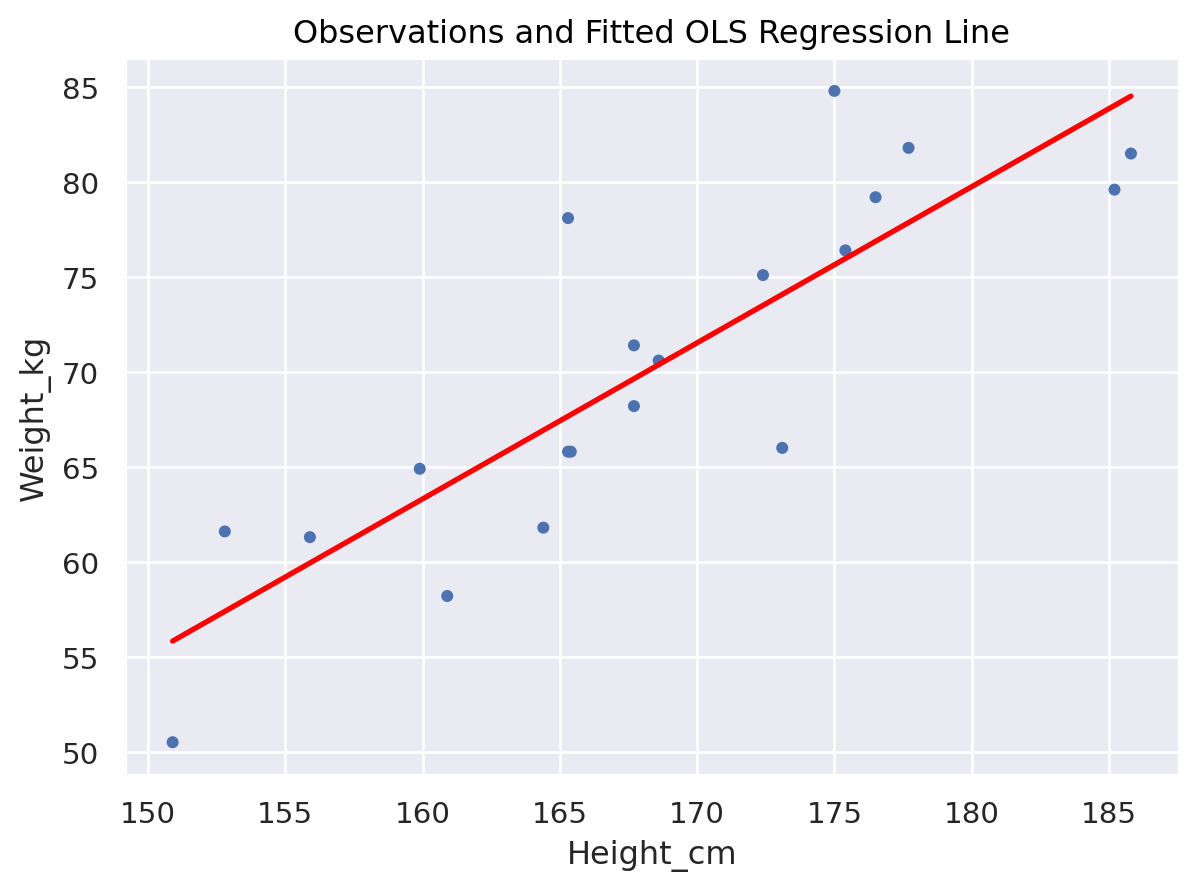

In [35]:
x_vals = df["Height_cm"]
y_vals=results.fittedvalues.values

(
   so.Plot(df, x="Height_cm", y="Weight_kg")
    .add(so.Dot( pointsize=4))
    .add(so.Line(color="red", linewidth=2), x=x_vals, y=y_vals)
    .label(title="Observations and Fitted OLS Regression Line")
)